## <center>Test Pratique  </center>

###  <span style="color:red">Consignes pour l'examen </span>

1- Veuillez enregistrer le code source selon le format suivant : "nom_prénom_classe"

2- Seuls les documents fournis par votre enseignant sont autorisés.

3- Internet n'est pas autorisée. Veuillez activer le mode avion et désactiver le Wifi.

4- Toute utilisation d'Internet (sur PC ou smartphone) sera considérée comme une tentative de fraude.

5- Lorsqu'un étudiant quitte la salle de classe, il n'est plus autorisé à récupérer le code source du travail effectué.

6- Veuillez vous assurer de vérifier soigneusement votre code avant la récupération. Chaque étudiant est responsable du code qu'il soumet, et aucune réclamation ne sera acceptée une fois que vous aurez quitté la salle.

# <span style="color:blue">Le jeu de données: penguins_lter.csv </span>

Le dataset **Penguins LTER** contient  des observations de différentes espèces de manchots étudiés dans le cadre du programme écologique LTER en Antarctique. Il regroupe des informations générales (espèce, île, région, identifiant), des données biologiques (stade de vie, ponte, date d’œuf), ainsi que des mesures morphologiques comme la longueur et la profondeur du bec, la longueur des nageoires, le poids et le sexe, avec quelques valeurs manquantes. Il inclut aussi des données isotopiques (delta 15N et delta 13C) utilisées pour analyser le régime alimentaire. Ce dataset est principalement utilisé pour des analyses écologiques, biométriques et des projets de classification en machine learning.



# Objectif:

1- Comprendre le jeu de données et le nettoyer.

2- Construire des modèles de classification

Dans cette étape, nous construisons des modèles de classification en utilisant le `DecisionTreeClassifier` afin de prédire l'une des trois espèces de manchots :

- **Adélie** (*Pygoscelis adeliae*)
- **Chinstrap** (*Pygoscelis antarctica*)
- **Gentoo** (*Pygoscelis papua*)

3-Optimiser également les hyperparamètres de l'algorithme DecisionTreeClassifier.

4-Utiliser les métriques d'évaluation de la classification pour evaluer le modèle.

##  1: Importer les bibliothèques requises <span style="color:green"> </span>

In [103]:
# Importations classiques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder, LabelEncoder


# Question 1: Importer le dataset "penguins_lter.csv" et l'enregistrer dans df (0.5pt).

In [5]:
# La bonne syntaxe pour Seaborn
df = sns.load_dataset("penguins")

# Question 2: Afficher les quatre premières lignes du dataset (0.5pt)

In [6]:
df.head(4)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN


# Question 3: Donner les informations sur la base de données (0.5pt).

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


# Question 4: Afficher la taille de la data (0.5pt).

In [30]:
print(df.shape)



df1=df.dropna(subset=['sex'])

print(df1.shape)

(333, 7)
(333, 7)


# Question 5: Déterminer le nombre de valeurs manquantes pour chaque colonne (0.5pt).


**Votre réponse:**................................................................


# Question 6: Quel est le nombre de valeurs manquantes de la variable et quelle mesure à proposer pour cette variable dans le cadre de préparation des données ?(1pt)


**Votre réponse:**...........................................................

# Question 7: Comment créer un tableau 2D `X` contenant les features suivantes :

- `Culmen Length (mm)`
- `Culmen Depth (mm)`
- `Flipper Length (mm)`
- `Body Mass (g)`
- `Island`
- `Sex`
  
# et un tableau 1D `y` contenant la target suivante :

- `Species` ?

# (1pt)


In [4]:
X = df1[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island', 'sex']]
y = df1['species']
print(X.columns)

NameError: name 'df1' is not defined

# Question 8: Remplacer les valeurs manquantes dans les variables numériques de X par leurs moyennes et de la variable *Sex* par son mode (1.5pt).

In [3]:
# Colonnes numériques 
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = X.copy()
# Remplissage des valeurs manquantes
X[num_cols] = X[num_cols].fillna(X[num_cols].mean())
X['sex'] = X['sex'].fillna(X['sex'].mode()[0])

NameError: name 'X' is not defined

# Question 9: vérifier que les valeurs manquantes ont été bien remplacées (0.5pt).

In [48]:
print(X.isnull().sum())

bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
island               0
sex                  0
dtype: int64


# Question 10: Écrire le code Python pour encoder les colonnes catégoriques de `X` en utilisant `OneHotEncoder`, afin de transformer chaque catégorie en colonnes binaires. Le tableau obtenu sera affecté à `X_cat_encoded` (1 pt).


In [61]:
# les variables catégorielles de X
cat_cols = ['island', 'sex']
# Instantiation de OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
# transformation des variables catégorielles et affectation 
X_cat_encoded = encoder.fit_transform(X[cat_cols])

# Question 11:  Exécuter le code suivant et décrire son fonctionnement : expliquer étape par étape ce que fait le code et quel est son résultat (0.5 pt).


In [63]:
cat_feature_names = encoder.get_feature_names_out(cat_cols)
X_cat_df = pd.DataFrame(X_cat_encoded, columns=cat_feature_names, index=X.index)
print(X_cat_df)

     island_Biscoe  island_Dream  island_Torgersen  sex_Female  sex_Male
0              0.0           0.0               1.0         0.0       1.0
1              0.0           0.0               1.0         1.0       0.0
2              0.0           0.0               1.0         1.0       0.0
4              0.0           0.0               1.0         1.0       0.0
5              0.0           0.0               1.0         0.0       1.0
..             ...           ...               ...         ...       ...
338            1.0           0.0               0.0         1.0       0.0
340            1.0           0.0               0.0         1.0       0.0
341            1.0           0.0               0.0         0.0       1.0
342            1.0           0.0               0.0         1.0       0.0
343            1.0           0.0               0.0         0.0       1.0

[333 rows x 5 columns]


**Votre réponse:**...................................................................

# Question 12: Encodage des données catégoriques de la colonne target `y` :  Utiliser `LabelEncoder` pour transformer la colonne `Species` du DataFrame et créer une nouvelle colonne `Species_encoded` contenant les valeurs encodées (1 pt).


In [67]:
# Instanciation de LabelEncoder
label= LabelEncoder()
# Transformation et affectation
Species_encoded =label.fit_transform(df1['species'])
# Conversion en série
y_encoded = pd.Series(Species_encoded)

# Question 13:  Standardisation des données numériques :  Compléter le code Python pour standardiser les colonnes numériques du DataFrame en utilisant `num_cols` et stocker le résultat dans `X_num_scaled` (1pt).


In [69]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X[num_cols])

# Question 14: Convertir X_num_scaled en DataFrame nommé `X_num_df` (1 pt).

In [1]:
X_num_df = pd.DataFrame(X_num_scaled,columns=num_cols)

NameError: name 'pd' is not defined

 # Question 15:  Exécuter le code suivant et expliquer son fonctionnement:  Décrire ce que fait chaque étape du code et quel est le résultat obtenu après son exécution (1 pt).


In [73]:
X_final = pd.concat([X_num_df, X_cat_df], axis=1)
print(X_final)

     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
0               0.0            0.0                0.0          0.0   
1               0.0            0.0                0.0          0.0   
2               0.0            0.0                0.0          0.0   
3               0.0            0.0                0.0          0.0   
4               0.0            0.0                0.0          0.0   
..              ...            ...                ...          ...   
338             NaN            NaN                NaN          NaN   
340             NaN            NaN                NaN          NaN   
341             NaN            NaN                NaN          NaN   
342             NaN            NaN                NaN          NaN   
343             NaN            NaN                NaN          NaN   

     island_Biscoe  island_Dream  island_Torgersen  sex_Female  sex_Male  
0              0.0           0.0               1.0         0.0       1.0  
1        

**Votre réponse:**.....................................................

# Question 16:  Analyse de la corrélation entre les variables :  Analyser la matrice de corrélation fournie en mettant l'accent sur le type de corrélation (positive, négative ou nulle) entre les features et la variable Target. (1pt).



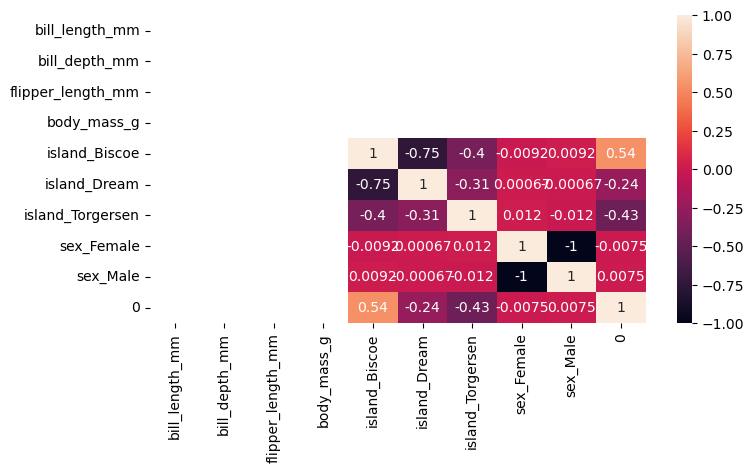

In [74]:
df_concat=pd.concat([X_final,y_encoded], axis=1)
cor=df_concat.corr()
plt.figure(figsize=(8,4))
sns.heatmap(cor,annot=True)
plt.show()

**Votre réponse:**.....................................................

# Question 17: Diviser la base `(X_final,y)` en deux ensembles : ensemble d'apprentissage (80%) et ensemble de test (20%) en fixant l'aléatoire à 0 et afficher la forme des 4 sous ensemble ( x_train, x_test, y_train et y_test ) (1pt)


In [94]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=True)
print("X_train :", X_train.shape)


X_train : (266, 9)


# Question 18: Créez un modèle d'arbre de décision  `dt` pour classer vos données. Utilisez le critère de Gini pour mesurer l'impureté des nœuds et limitez la profondeur maximale de l'arbre à 3 (1pt).

In [95]:
dt=DecisionTreeClassifier(criterion='gini',max_depth=3,random_state=0)

# Question 19 : Entraînez le modèle d'arbre de décision `dt` sur les données d'entraînement (0,5pts).

In [96]:

dt.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Question 20 : Calculer "y_pred" et afficher le __`classification_report`__ de `dt` (0.5 pt).

In [100]:
from sklearn.metrics import classification_report

y_pred=dt.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      Adelie       1.00      0.39      0.56        28
   Chinstrap       0.63      1.00      0.77        17
      Gentoo       0.76      1.00      0.86        22

    accuracy                           0.75        67
   macro avg       0.80      0.80      0.73        67
weighted avg       0.83      0.75      0.72        67



# Question 21: Analyser le rapport de classification (1pt).

**Votre réponse :**C'est un modèle qui "détecte" bien (bon rappel pour Chinstrap/Gentoo) mais qui manque de "finesse" (mauvaise précision pour Chinstrap et mauvais rappel pour Adelie).

# Question 22: Compléter ce code pour afficher la matrice de confusion  pour évaluer la qualité des prédictions du modèle (1.5pt).

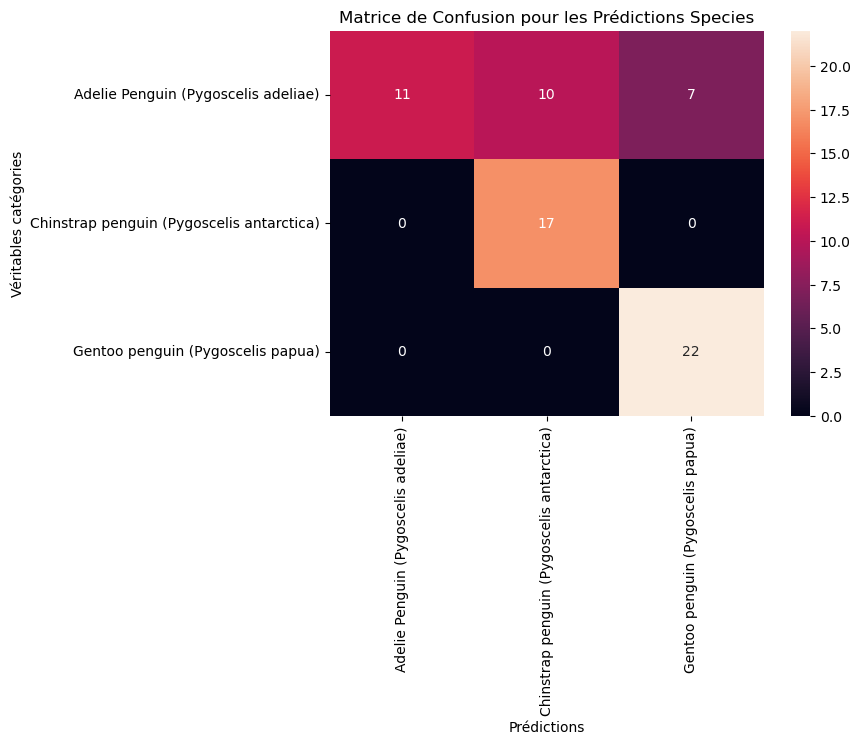

In [102]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calcul de la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)
# Visualiser la matrice de confusion avec un heatmap
plt.figure(figsize=(7, 5), dpi=100)
sns.heatmap(conf_matrix, annot=True, fmt="d",
            xticklabels=['Adelie Penguin (Pygoscelis adeliae)','Chinstrap penguin (Pygoscelis antarctica)','Gentoo penguin (Pygoscelis papua)'],
            yticklabels=['Adelie Penguin (Pygoscelis adeliae)','Chinstrap penguin (Pygoscelis antarctica)','Gentoo penguin (Pygoscelis papua)'])
plt.ylabel('Véritables catégories')
plt.xlabel('Prédictions')
plt.title('Matrice de Confusion pour les Prédictions Species')
plt.show()


#  Question 23: Analyser la matrice de confusion (1.5pt).

**Votre réponse:**...............................................